**STEP 1**

In [1]:
pip install html-table-parser-python3

In [40]:
#To choose ten stocks from the S&P 500 we need to see which of them are performing well.
#We'll begin by accessing the table of the 500 stocks from wikipedia

# import the library for opening url and creating requests
import urllib.request
# import lib for parsing ie. analyzing all the tables present on the website
from html_table_parser.parser import HTMLTableParser
import pandas as pd

#defining a function to get the contents from a given url and reading content
def url_get_contents(url):

    req = urllib.request.Request(url=url)
    f = urllib.request.urlopen(req)
    return f.read()

# defining the html contents of a URL.
html_contents = url_get_contents('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies').decode('utf-8')

# feeding the html contents in the HTMLTableParser object to get all the tables on the webpage
HTMLTableParser().feed(html_contents)


In [41]:
#the table we need is the first one -> index 0
table = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
#from the table columns we make a list of the tickers of the stocks
tickers = table['Symbol'].tolist()
print(tickers)

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK.B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF.B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COIN', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DVA', '

In [42]:
import yfinance as yf
import pandas as pd

#tried without the following line and it throws an error for BRK.B  (+1 stock) because yf has it as BRK-B
tickers = [t.replace('.', '-') for t in tickers]

#download data for last 5 years for all the tickers to analyse their performance
#set auto_adjust to false to get the adj close column
data = yf.download(tickers, start="2020-01-01", end="2025-01-01",
                   progress=True, threads=True, auto_adjust=False)

#the df we get it a multi index one. Now we access the index at level 0 ie. Adj CLose and make a new df
adj_close = data['Adj Close']

[*********************100%***********************]  503 of 503 completed


In [43]:
#now we'll choose the best stocks on the bases of sharpe ratio
import numpy as np

#make empty dictionary to arrange each ticker with it's sharpe ratio, annual return and volatility
sharpe_data = {}

for ticker in adj_close.columns:
  #drop all missing data
    price_series = adj_close[ticker].dropna()

    #To handle missing values we'll drop stocks that have more than 2 yrs of missing data ie. less than 3yrs
    if len(price_series) >= 756:
        risk_free_rate = 0.044
        returns = price_series.pct_change().dropna()
        ann_return = returns.mean() * 252
        ann_vol = returns.std() * np.sqrt(252)
        sharpe = (ann_return - risk_free_rate) / ann_vol

        sharpe_data[ticker] = {
            'Annual Return': ann_return,
            'Annual Volatility': ann_vol,
            'Sharpe Ratio': sharpe
        }

#convert the dictionary to DataFrame
sharpe_df = pd.DataFrame.from_dict(sharpe_data, orient='index')

#sort the dataframe and get top 10 stocks
top_10 = sharpe_df.sort_values('Sharpe Ratio', ascending=False).head(10)
print(top_10)


      Annual Return  Annual Volatility  Sharpe Ratio
NVDA       0.768567           0.538788      1.344807
PWR        0.478926           0.367516      1.183421
LLY        0.419069           0.325648      1.151763
ANET       0.522740           0.427186      1.120685
AVGO       0.511343           0.418915      1.115603
CARR       0.448133           0.379655      1.064473
TSLA       0.755347           0.671815      1.058844
DECK       0.489180           0.441009      1.009458
VST        0.484075           0.438772      1.002970
MCK        0.332492           0.289812      0.995447


In [44]:
import yfinance as yf

#Now we had to ensure that the stocks are from diverse sectors so we fetch sector info for top 10 stocks
sector_map = {}
for ticker in top_10.index:
  info = yf.Ticker(ticker).info
  top_10.loc[ticker, "Sector"] = info.get('sector', 'N/A')
print(top_10)

      Annual Return  Annual Volatility  Sharpe Ratio             Sector
NVDA       0.768567           0.538788      1.344807         Technology
PWR        0.478926           0.367516      1.183421        Industrials
LLY        0.419069           0.325648      1.151763         Healthcare
ANET       0.522740           0.427186      1.120685         Technology
AVGO       0.511343           0.418915      1.115603         Technology
CARR       0.448133           0.379655      1.064473        Industrials
TSLA       0.755347           0.671815      1.058844  Consumer Cyclical
DECK       0.489180           0.441009      1.009458  Consumer Cyclical
VST        0.484075           0.438772      1.002970          Utilities
MCK        0.332492           0.289812      0.995447         Healthcare


Since I have found top 10 companies based on the sharpe ratio over the past five years and because they are from diverse sectors, I'll take these 10 for my efficient frontier.

**STEP 2**

In [45]:
#make a list of the tickers and get their data
chosen_tickers = top_10.index.tolist()
data = yf.download(chosen_tickers, start="2020-01-01", end="2025-01-01", progress=True, auto_adjust = False)

# Keep only the adjusted close prices since we only need to work with them
chosen_adj_close = data['Adj Close']

[*********************100%***********************]  10 of 10 completed


In [46]:
#handle missing values by dropping all rows with missing data
chosen_adj_close_cleaned = chosen_adj_close.dropna()

**STEP 3**

In [47]:
import numpy as np

#calculate daily logarithmic returns by taking ln of ratio of closing price today by yesterday
log_returns = np.log(chosen_adj_close_cleaned / chosen_adj_close_cleaned.shift(1)).dropna()

#for annualized mean returns we multiply mean of the log of returns with the no. of trading days ~ 252
trading_days = 252
annualized_mean_returns = log_returns.mean() * trading_days

# for covariance matrix we use the .cov function
annualized_cov_matrix = log_returns.cov() * trading_days

print("Annualized Mean Returns:\n", annualized_mean_returns)
print("\nAnnualized Covariance Matrix:\n", annualized_cov_matrix)


Annualized Mean Returns:
 Ticker
ANET    0.480719
AVGO    0.548356
CARR    0.377234
DECK    0.515580
LLY     0.380424
MCK     0.320520
NVDA    0.676322
PWR     0.517591
TSLA    0.554816
VST     0.501004
dtype: float64

Annualized Covariance Matrix:
 Ticker      ANET      AVGO      CARR      DECK       LLY       MCK      NVDA  \
Ticker                                                                         
ANET    0.170643  0.097085  0.048454  0.065136  0.028939  0.024770  0.123249   
AVGO    0.097085  0.147472  0.051305  0.068095  0.027547  0.016371  0.129306   
CARR    0.048454  0.051305  0.140073  0.050522  0.014600  0.019162  0.056685   
DECK    0.065136  0.068095  0.050522  0.172939  0.019620  0.021857  0.090486   
LLY     0.028939  0.027547  0.014600  0.019620  0.095001  0.020342  0.035640   
MCK     0.024770  0.016371  0.019162  0.021857  0.020342  0.069719  0.018911   
NVDA    0.123249  0.129306  0.056685  0.090486  0.035640  0.018911  0.267852   
PWR     0.061055  0.059428  0.

**STEP 4**

In [48]:
port_num = 50000
assets_num = 10

#prepare arrays to hold results for the 10 chosen stocks
results = {
    'Return': [],
    'Volatility': [],
    'Sharpe': [],
}
#also add a weight columnn for each ticker
for ticker in chosen_tickers:
  results[f'Weight_{ticker}'] = []

#now we assign random weights to the stocks and normalize them to 1
for num in range(port_num):
    weights = np.random.random(assets_num)
    weights = weights/np.sum(weights)  # Normalize to sum to 1

    #for each portfolio we calculate the annualized mean returns and variance
    portfolio_return = 0
    for i in range(10):
      portfolio_return = portfolio_return + weights[i]*annualized_mean_returns[i]

    portfolio_variance = 0
    cov_matrix_array = annualized_cov_matrix.values
    # Nested loops over all asset pairs
    for i in range(assets_num):
      for j in range(assets_num):
        portfolio_variance += weights[i] * weights[j] * cov_matrix_array[i][j]

    portfolio_volatility = np.sqrt(portfolio_variance)

    #now we take risk_free_rate as 0 and calculate sharpe_ratio
    risk_free_rate = 0
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    #store return, volatility and sharpe ratio for all 5000 portfolios
    results['Return'].append(portfolio_return)
    results['Volatility'].append(portfolio_volatility)
    results['Sharpe'].append(sharpe_ratio)
    for i, ticker in enumerate(chosen_tickers):
        results[f'Weight_{ticker}'].append(weights[i])

#results was a dictionary or lists which we now convert to a df
portfolio_df = pd.DataFrame(results)

#print top few portfolios by Sharpe ratio
top_10 = portfolio_df.sort_values(by='Sharpe', ascending=False).head(10)
print(top_10)


<ipython-input-48-613d3599f22a>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portfolio_return = portfolio_return + weights[i]*annualized_mean_returns[i]


         Return  Volatility    Sharpe  Weight_NVDA  Weight_PWR  Weight_LLY  \
37445  0.454737    0.219015  2.076286     0.006932    0.147592    0.057370   
32247  0.462552    0.223054  2.073721     0.012030    0.178518    0.009656   
45651  0.449708    0.216905  2.073291     0.001022    0.123975    0.096739   
36866  0.428771    0.207109  2.070266     0.009615    0.139260    0.075586   
20809  0.446487    0.216099  2.066125     0.037221    0.127225    0.039357   
8182   0.463437    0.224514  2.064177     0.005042    0.120732    0.014499   
14131  0.454344    0.220330  2.062105     0.049207    0.140918    0.047026   
28675  0.450084    0.218273  2.062023     0.043617    0.154700    0.045455   
43075  0.460557    0.223547  2.060229     0.015244    0.140007    0.054512   
5891   0.455411    0.221083  2.059913     0.006959    0.171789    0.049533   

       Weight_ANET  Weight_AVGO  Weight_CARR  Weight_TSLA  Weight_DECK  \
37445     0.073084     0.174897     0.204395     0.039002     0.188

**STEP 5**

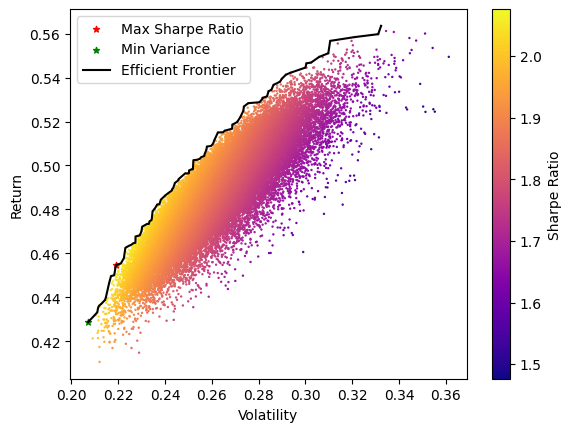

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

#now we make a scatter plot of volatility vs return and mark portfolios with max sharpe ratio and min variance
x = portfolio_df['Volatility']
y = portfolio_df['Return']
color_scheme = portfolio_df['Sharpe']
plt.scatter(x, y, s = 0.5, c = color_scheme, cmap = 'plasma')
plt.colorbar(label = 'Sharpe Ratio')
plt.xlabel("Volatility")
plt.ylabel("Return")

max_sharpe = portfolio_df.loc[portfolio_df['Sharpe'].idxmax()]
plt.scatter(max_sharpe['Volatility'], max_sharpe['Return'],
            color='red', marker='*', s=20, label='Max Sharpe Ratio')

min_variance = portfolio_df.loc[portfolio_df['Volatility'].idxmin()]
plt.scatter(min_variance['Volatility'], min_variance['Return'],
            color='green', marker='*', s=20, label='Min Variance')

sorted_vol = portfolio_df.sort_values('Volatility')

efficient_vol = []
efficient_ret = []

#setting the return till now to minus infinity so that any first return would be greater
max_return_so_far = -np.inf

for i in range(len(sorted_vol)):
    current_return = sorted_vol.iloc[i]['Return']
    current_vol = sorted_vol.iloc[i]['Volatility']
    if current_return > max_return_so_far:
        efficient_vol.append(current_vol)
        efficient_ret.append(current_return)
        max_return_so_far = current_return

#Now efficient frontier will have only the points where the return is increasing
plt.plot(efficient_vol, efficient_ret, color='black', linewidth=1.5, label='Efficient Frontier')

plt.legend()

plt.show()

I did the plot for efficient frontier but unlike the graphs I referred to, this line is jagged. I don't know why this is happening.

**STEP 6**

In [15]:
from scipy.optimize import minimize
#assets_num = 10

#convert to arrays for optimization
annualized_mean_returns_array = annualized_mean_returns.values
#cov_matrix_array = annualized_cov_matrix.values

def weight_sum_to_1(x):
    return np.sum(x) - 1
#set constraints
constraints = ({'type': 'eq', 'fun': weight_sum_to_1})
#for type eq that is equality, fun that is function should equal zero.

#set bounds
bounds_list = []
for num in range(assets_num):
  bounds_list.append((0, 1))

#bounds have to be tuples not lists
bounds = tuple(bounds_list)



In [26]:
#define a function to calculate volatility which we will minimized
def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

#start with an initial guess of equally distributed weights
init_guess = assets_num * [1. / assets_num]

#now we minimize the function we had defined above to find weights for min volatility
min_var_result = minimize(portfolio_volatility, init_guess,
                          args=(cov_matrix_array,),
                          method='SLSQP', bounds=bounds,
                          constraints=constraints)

min_var_weights = min_var_result.x
print("Minimum Variance Portfolio Weights:\n", min_var_weights)

Minimum Variance Portfolio Weights:
 [0.00000000e+00 6.04456283e-02 1.15283671e-01 4.96235756e-02
 2.58927308e-01 3.87436713e-01 1.40946282e-18 5.45330226e-02
 2.01764899e-02 5.35735910e-02]


In [27]:
#define a function to return neg of the sharpe ratio which we will minimize to maximize sharpe ratio
def negative_sharpe_ratio(weights, mean_returns, cov_matrix):
    port_return = np.dot(weights, mean_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -port_return / port_volatility

#now we use optimization to find the weights for which sharpe ratio is max subject to constraints
max_sharpe_result = minimize(negative_sharpe_ratio, init_guess,
                             args=(annualized_mean_returns_array, cov_matrix_array),
                             method='SLSQP', bounds=bounds,
                             constraints=constraints)

max_sharpe_weights = max_sharpe_result.x
print("Maximum Sharpe Ratio Portfolio Weights:\n", max_sharpe_weights)

Maximum Sharpe Ratio Portfolio Weights:
 [2.71448555e-17 1.17264104e-01 3.06213880e-02 7.91986565e-02
 2.22373630e-01 2.40978612e-01 4.71674427e-02 1.43574189e-01
 2.25229194e-02 9.62990586e-02]


In [25]:
#now we define a function to print the return, volatility and sharpe ratio of the two porfolios
def print_portfolio_summary(weights, name):
    ret = np.dot(weights, annualized_mean_returns_array)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_array, weights)))
    sharpe = ret / vol
    print(f"\n{name} Portfolio:")
    print("Return: {:.4f}, Volatility: {:.4f}, Sharpe Ratio: {:.4f}".format(ret, vol, sharpe))

print_portfolio_summary(min_var_weights, "Minimum Variance")
print_portfolio_summary(max_sharpe_weights, "Maximum Sharpe Ratio")



Minimum Variance Portfolio:
Return: 0.3912, Volatility: 0.1987, Sharpe Ratio: 1.9685

Maximum Sharpe Ratio Portfolio:
Return: 0.4455, Volatility: 0.2128, Sharpe Ratio: 2.0933


**STEP 7**

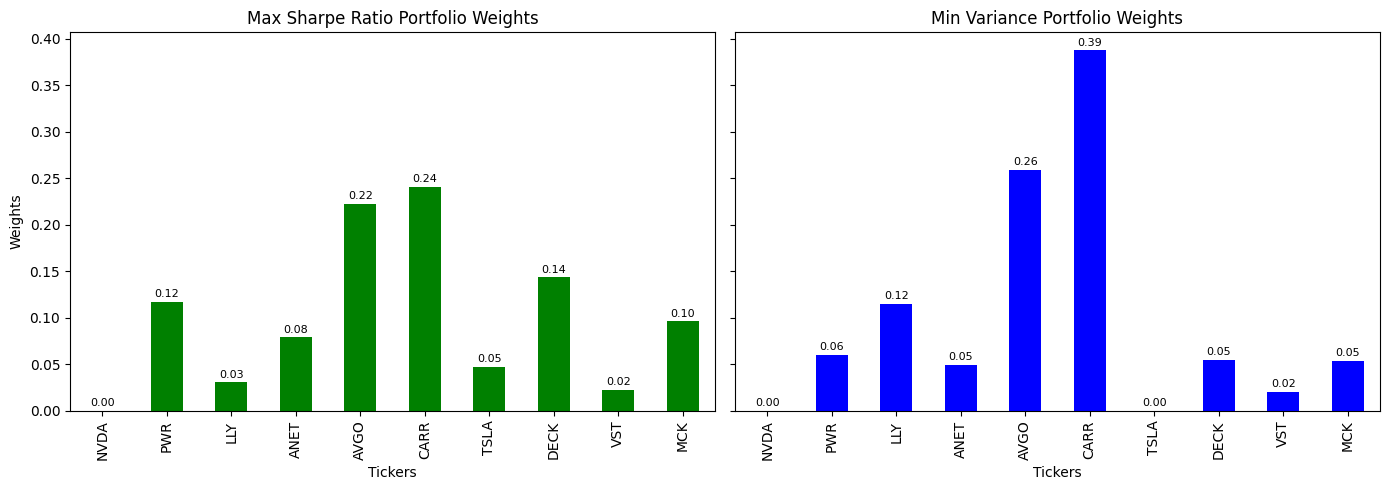

In [36]:
#we have already plotted all the other plots required. Only need to do the weigths one
max_sharpe_weights_series = pd.Series(max_sharpe_weights, index=chosen_tickers)
min_var_weights_series = pd.Series(min_var_weights, index=chosen_tickers)

#plotting both as subplots to compare them side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

#plottin the Max Sharpe Rati  o Portfolio Weights
max_sharpe_weights_series.plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title("Max Sharpe Ratio Portfolio Weights")
axes[0].set_ylabel("Weights")
axes[0].set_xlabel("Tickers")
for i, (ticker, weight) in enumerate(max_sharpe_weights_series.items()):
    axes[0].text(i, weight + 0.005, f"{weight:.2f}", ha='center', fontsize=8)

#plotting the Min Variance Portfolio Weights
min_var_weights_series.plot(kind='bar', ax=axes[1], color='blue')
axes[1].set_title("Min Variance Portfolio Weights")
axes[1].set_xlabel("Tickers")
for i, (ticker, weight) in enumerate(min_var_weights_series.items()):
    axes[1].text(i, weight + 0.005, f"{weight:.2f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()
